<a href="https://colab.research.google.com/github/MamoMGD1/ML_101/blob/main/currency.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

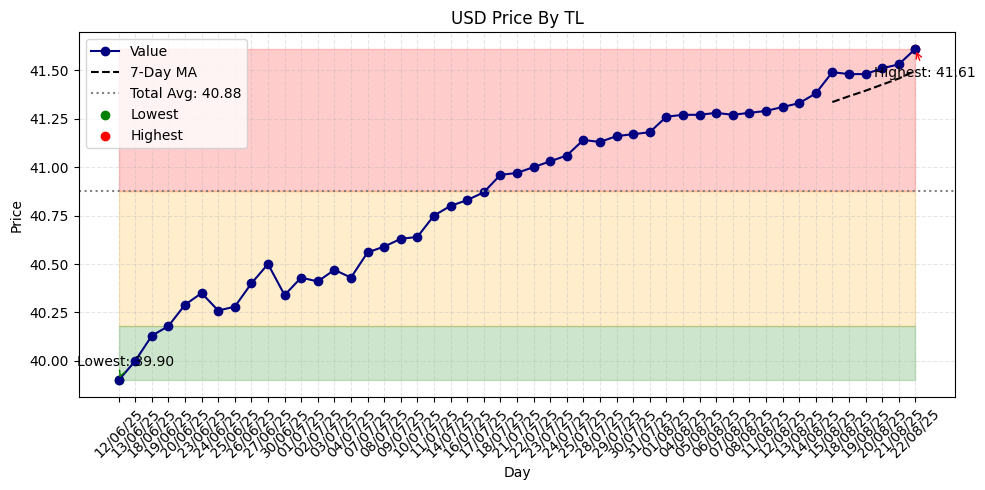

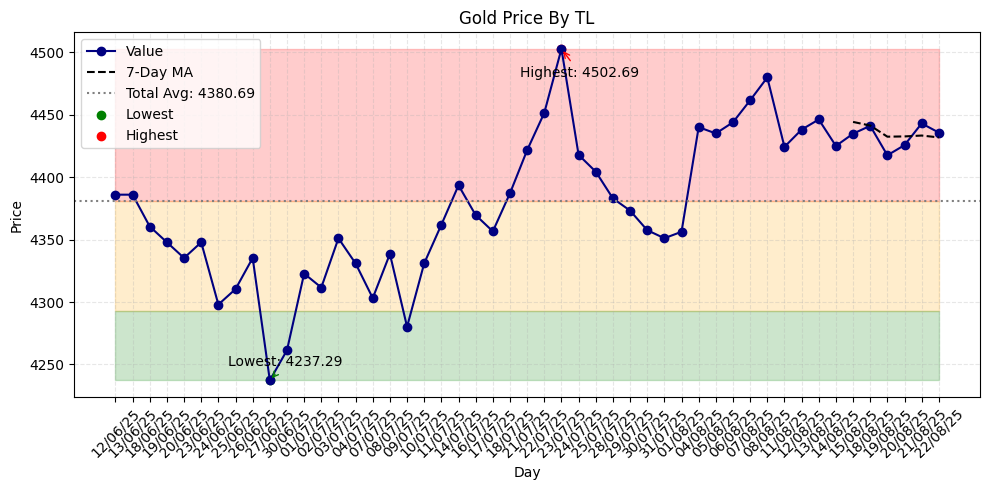

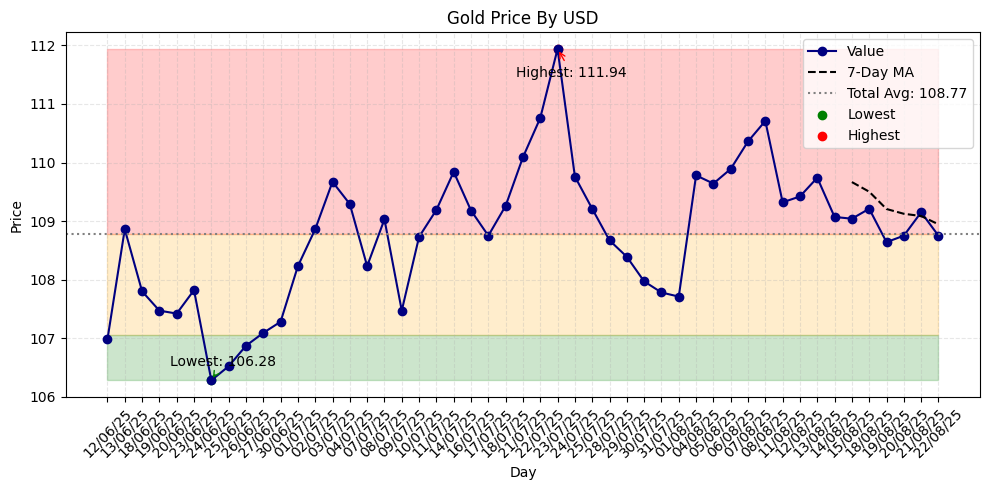

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

def draw_plot(days,values,title=''):

  def moving_average(values, window=7):
    ma = []
    for i in range(len(values)):
      if i <= len(values) - window:
          ma.append(None)  # not enough data yet
      else:
          window_slice = values[i - window + 1 : i + 1]
          ma.append(sum(window_slice) / window)
    return ma

  cur_ma = moving_average(values)

  cur_avg = np.mean(values)

  std = np.std(values)
  bad_zone = [cur_avg,np.max(values)]
  medium_zone = [cur_avg-1.5*std,cur_avg]
  buy_zone = [np.min(values),medium_zone[0]]

  # start plotting all the data
  plt.figure(figsize=(10,5))

  plt.fill_between(days, bad_zone[0], bad_zone[1], color='red', alpha=0.2)
  plt.fill_between(days, medium_zone[0], medium_zone[1], color='orange', alpha=0.2)
  plt.fill_between(days, buy_zone[0], buy_zone[1], color='green', alpha=0.2)

  plt.plot(days, values, color="navy", marker="o", label="Value")
  plt.plot(days, cur_ma, color="black", linestyle="--", label="7-Day MA")
  plt.axhline(y=cur_avg, color="gray", linestyle=":", label=f"Total Avg: {cur_avg:.2f}")

  min_idx = values.index(min(values))
  max_idx = values.index(max(values))
  plt.scatter(days[min_idx], values[min_idx], color="green", label="Lowest")
  plt.scatter(days[max_idx], values[max_idx], color="red", label="Highest")

  plt.annotate(f"Lowest: {values[min_idx]:.2f}",
             xy=(days[min_idx], values[min_idx]),
             xytext=(-30, 10), textcoords='offset points',
             arrowprops=dict(arrowstyle="->", color="green"))

  plt.annotate(f"Highest: {values[max_idx]:.2f}",
             xy=(days[max_idx], values[max_idx]),
             xytext=(-30, -20), textcoords='offset points',
             arrowprops=dict(arrowstyle="->", color="red"))

  plt.title(title)
  plt.xlabel("Day")
  plt.ylabel("Price")
  plt.xticks(rotation=45)
  plt.legend()
  plt.grid(True, linestyle="--", alpha=0.3)
  plt.tight_layout()
  plt.show()

data = get_data()

# extract data
days = [d["day"] for d in data]

usd_values = [d["usd"] for d in data]
gold_values = [d["gold"] for d in data]
usd_gold_values = [d["usd_gold"] for d in data]

# draw plots
draw_plot(days,usd_values,'USD Price By TL')
draw_plot(days,gold_values,'Gold Price By TL')
draw_plot(days,usd_gold_values,'Gold Price By USD')

In [ ]:
def get_data():
  return[
    {"day": "12/06/25", "usd": 39.90, "gold": 4385.96, "usd_gold": 106.98},
    {"day": "13/06/25", "usd": 40.00, "gold": 4385.96, "usd_gold": 108.86},
    {"day": "18/06/25", "usd": 40.13, "gold": 4360.46, "usd_gold": 107.80},
    {"day": "19/06/25", "usd": 40.18, "gold": 4347.83, "usd_gold": 107.47},
    {"day": "20/06/25", "usd": 40.29, "gold": 4335.26, "usd_gold": 107.42},
    {"day": "23/06/25", "usd": 40.35, "gold": 4347.83, "usd_gold": 107.82},
    {"day": "24/06/25", "usd": 40.26, "gold": 4297.99, "usd_gold": 106.28},
    {"day": "25/06/25", "usd": 40.28, "gold": 4310.34, "usd_gold": 106.52},
    {"day": "26/06/25", "usd": 40.40, "gold": 4335.26, "usd_gold": 106.87},
    {"day": "27/06/25", "usd": 40.50, "gold": 4237.29, "usd_gold": 107.09},
    {"day": "30/06/25", "usd": 40.34, "gold": 4261.36, "usd_gold": 107.28},
    {"day": "01/07/25", "usd": 40.43, "gold": 4322.77, "usd_gold": 108.23},
    {"day": "02/07/25", "usd": 40.41, "gold": 4311.61, "usd_gold": 108.86},
    {"day": "03/07/25", "usd": 40.47, "gold": 4351.01, "usd_gold": 109.67},
    {"day": "04/07/25", "usd": 40.43, "gold": 4330.88, "usd_gold": 109.29},
    {"day": "07/07/25", "usd": 40.56, "gold": 4303.14, "usd_gold": 108.23},
    {"day": "08/07/25", "usd": 40.59, "gold": 4338.52, "usd_gold": 109.03},
    {"day": "09/07/25", "usd": 40.63, "gold": 4280.17, "usd_gold": 107.47},
    {"day": "10/07/25", "usd": 40.64, "gold": 4331.01, "usd_gold": 108.73},
    {"day": "11/07/25", "usd": 40.75, "gold": 4361.89, "usd_gold": 109.19},
    {"day": "14/07/25", "usd": 40.80, "gold": 4393.45, "usd_gold": 109.84},
    {"day": "16/07/25", "usd": 40.83, "gold": 4369.59, "usd_gold": 109.18},
    {"day": "17/07/25", "usd": 40.87, "gold": 4356.58, "usd_gold": 108.75},
    {"day": "18/07/25", "usd": 40.96, "gold": 4387.09, "usd_gold": 109.26},
    {"day": "21/07/25", "usd": 40.97, "gold": 4421.58, "usd_gold": 110.09},
    {"day": "22/07/25", "usd": 41.00, "gold": 4451.48, "usd_gold": 110.76},
    {"day": "23/07/25", "usd": 41.03, "gold": 4502.69, "usd_gold": 111.94},
    {"day": "24/07/25", "usd": 41.06, "gold": 4417.81, "usd_gold": 109.76},
    {"day": "25/07/25", "usd": 41.14, "gold": 4404.38, "usd_gold": 109.21},
    {"day": "28/07/25", "usd": 41.13, "gold": 4382.98, "usd_gold": 108.67},
    {"day": "29/07/25", "usd": 41.16, "gold": 4373.21, "usd_gold": 108.39},
    {"day": "30/07/25", "usd": 41.17, "gold": 4357.52, "usd_gold": 107.97},
    {"day": "31/07/25", "usd": 41.18, "gold": 4351.07, "usd_gold": 107.78},
    {"day": "01/08/25", "usd": 41.26, "gold": 4356.24, "usd_gold": 107.71},
    {"day": "04/08/25", "usd": 41.27, "gold": 4440.03, "usd_gold": 109.78},
    {"day": "05/08/25", "usd": 41.27, "gold": 4434.98, "usd_gold": 109.64},
    {"day": "06/08/25", "usd": 41.28, "gold": 4443.92, "usd_gold": 109.89},
    {"day": "07/08/25", "usd": 41.27, "gold": 4461.52, "usd_gold": 110.36},
    {"day": "08/08/25", "usd": 41.28, "gold": 4479.83, "usd_gold": 110.71},
    {"day": "11/08/25", "usd": 41.29, "gold": 4424.23, "usd_gold": 109.32},
    {"day": "12/08/25", "usd": 41.31, "gold": 4438.05, "usd_gold": 109.42},
    {"day": "13/08/25", "usd": 41.33, "gold": 4446.17, "usd_gold": 109.74},
    {"day": "14/08/25", "usd": 41.38, "gold": 4424.99, "usd_gold": 109.07},
    {"day": "15/08/25", "usd": 41.49, "gold": 4434.80, "usd_gold": 109.04},
    {"day": "18/08/25", "usd": 41.48, "gold": 4441.09, "usd_gold": 109.21},
    {"day": "19/08/25", "usd": 41.48, "gold": 4417.49, "usd_gold": 108.64},
    {"day": "20/08/25", "usd": 41.51, "gold": 4425.64, "usd_gold": 108.75},
    {"day": "21/08/25", "usd": 41.53, "gold": 4443.00, "usd_gold": 109.15},
    {"day": "22/08/25", "usd": 41.61, "gold": 4435.67, "usd_gold": 108.75}
]

#**RED ZONE**

In [ ]:
! pip install torchsummary

In [ ]:
from matplotlib import pyplot as plt
from tqdm import trange
import torch
import torch.nn as nn
from torch.optim import Adam
import torch.nn.functional as F
from torch.nn import CrossEntropyLoss
from torch.utils.data import DataLoader
from torchvision import transforms, models
from torchvision.datasets.cifar import CIFAR10
from torchsummary import summary

torch.manual_seed(42)
device = torch.device('cuda') if torch.cuda.is_available() else torch.device('cpu')

In [ ]:
norm_mean = (0.4914, 0.4822, 0.4465)
norm_std = (0.2023, 0.1994, 0.2010)
batch_size = 128

transform_train = transforms.Compose([
    transforms.RandomCrop(32, padding=4),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(norm_mean, norm_std),
])

transform_test = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(norm_mean, norm_std),
])

trainset = CIFAR10(root='./data', train=True, download=True, transform=transform_train)
trainloader = DataLoader(trainset, batch_size=batch_size, shuffle=True, num_workers=2)

testset = CIFAR10(root='./data', train=False, download=True, transform=transform_test)
testloader = DataLoader(testset, batch_size=batch_size, shuffle=False, num_workers=2)


classes = ('plane', 'car', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck')

100%|██████████| 170M/170M [00:01<00:00, 107MB/s]


In [ ]:
def train_epoch(model, loss_fn, optimizer, dataloader=trainloader):
    model.train()
    train_loss = 0.
    train_acc = 0.
    for images, labels in dataloader:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        logits = model(images)
        loss = loss_fn(logits, labels)
        loss.backward()
        optimizer.step()
        train_loss += loss.item()
        train_acc += (logits.argmax(dim=1) == labels).sum().item()
    train_loss /= len(dataloader)
    train_acc /= len(dataloader.dataset)
    return train_loss, 100 * train_acc


def validate_epoch(model, loss_fn, dataloader=testloader):
    model.eval()
    val_loss = 0.
    val_acc = 0.
    with torch.inference_mode():
        for images, labels in dataloader:
            images, labels = images.to(device), labels.to(device)
            logits = model(images)
            loss = loss_fn(logits, labels)
            val_loss += loss.item()
            val_acc += (logits.argmax(dim=1) == labels).sum().item()
        val_loss /= len(dataloader)
        val_acc /= len(dataloader.dataset)
    return val_loss, 100 * val_acc


def train_model(model, optimizer, n_epochs):
    history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}
    loss_fn = CrossEntropyLoss()
    for _ in (pbar := trange(n_epochs)):
        train_loss, train_acc = train_epoch(model, loss_fn, optimizer)
        history['train_loss'].append(train_loss), history['train_acc'].append(train_acc)
        val_loss, val_acc = validate_epoch(model, loss_fn)
        history['val_loss'].append(val_loss), history['val_acc'].append(val_acc)
        pbar.set_description(f'Training Accuracy {train_acc:.2f}% | Validation Accuracy {val_acc:.2f}% ')
    return history


def plot_training_curves(results):
    epochs_range = range(1, len(results['train_loss']) + 1)

    plt.figure(figsize=(14, 5))

    # Plot training and validation loss
    plt.subplot(1, 2, 1)
    plt.plot(epochs_range, results['train_loss'], label='Train Loss')
    plt.plot(epochs_range, results['val_loss'], label='Validation Loss')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.title('Training and Validation Loss')
    plt.xticks(epochs_range)  # Adding ticks for epochs
    plt.legend()

    # Plot training and validation accuracy
    plt.subplot(1, 2, 2)
    plt.plot(epochs_range, results['train_acc'], label='Train Accuracy')
    plt.plot(epochs_range, results['val_acc'], label='Validation Accuracy')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy (%)')
    plt.title('Training and Validation Accuracy')
    plt.xticks(epochs_range)  # Adding ticks for epochs
    plt.yticks(range(0, 101, 10))  # Accuracy range from 0 to 100
    plt.legend()

    plt.tight_layout()
    plt.show()


def compare_results(m1_name, m1_results, m2_name, m2_results):
    epochs_range = range(1, len(m1_results['val_loss']) + 1)

    plt.figure(figsize=(14, 5))

    # Plot training and validation loss
    plt.subplot(1, 2, 1)
    plt.plot(epochs_range, m1_results['val_loss'], label=f'{m1_name}')
    plt.plot(epochs_range, m2_results['val_loss'], label=f'{m2_name}')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.title('Loss')
    plt.xticks(epochs_range)  # Adding ticks for epochs
    plt.legend()

    plt.subplot(1, 2, 2)
    plt.plot(epochs_range, m1_results['val_acc'], label=f'{m1_name}')
    plt.plot(epochs_range, m2_results['val_acc'], label=f'{m2_name}')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy (%)')
    plt.title('Accuracy')
    plt.xticks(epochs_range)  # Adding ticks for epochs
    plt.yticks(range(0, 101, 10))  # Accuracy range from 0 to 100
    plt.legend()

    plt.tight_layout()
    plt.show()

In [ ]:
class BasicBlock(nn.Module):
    expansion = 1  # BasicBlock does not expand channels

    def __init__(self, in_channels, out_channels, stride=1, downsample=None):
        super(BasicBlock, self).__init__()
        self.conv1 = nn.Conv2d(in_channels, out_channels, kernel_size=3, stride=stride, padding=1, bias=False)
        self.bn1 = nn.BatchNorm2d(out_channels)
        self.relu = nn.ReLU(inplace=True)
        self.conv2 = nn.Conv2d(out_channels, out_channels, kernel_size=3, stride=1, padding=1, bias=False)
        self.bn2 = nn.BatchNorm2d(out_channels)

    def forward(self, x):
        out = self.conv1(x)
        out = self.bn1(out)
        out = self.relu(out)

        out = self.conv2(out)
        out = self.bn2(out)

        out = self.relu(out)

        return out

In [ ]:
class ResNet(nn.Module):
    def __init__(self, block, layers, num_classes=10):
        super(ResNet, self).__init__()
        self.in_channels = 16  # CIFAR-10 starts with 16 filters

        # Initial convolution layer
        self.conv1 = nn.Conv2d(3, 16, kernel_size=3, stride=1, padding=1, bias=False)
        self.bn1 = nn.BatchNorm2d(16)
        self.relu = nn.ReLU(inplace=True)

        # Residual layers
        self.layer1 = self._make_layer(block, 16, layers[0], stride=1)  # 32x32
        self.layer2 = self._make_layer(block, 32, layers[1], stride=2)  # 16x16
        self.layer3 = self._make_layer(block, 64, layers[2], stride=2)  # 8x8

        # Global average pooling and fully connected layer
        self.avgpool = nn.AdaptiveAvgPool2d((1, 1))
        self.fc = nn.Linear(64 * block.expansion, num_classes)

    def _make_layer(self, block, out_channels, blocks, stride):
        downsample = None
        if stride != 1 or self.in_channels != out_channels * block.expansion:
            downsample = nn.Sequential(
                nn.Conv2d(self.in_channels, out_channels * block.expansion, kernel_size=1, stride=stride, bias=False),
                nn.BatchNorm2d(out_channels * block.expansion),
            )

        layers = []
        layers.append(block(self.in_channels, out_channels, stride, downsample))
        self.in_channels = out_channels * block.expansion
        for _ in range(1, blocks):
            layers.append(block(self.in_channels, out_channels))

        return nn.Sequential(*layers)

    def forward(self, x):
        x = self.conv1(x)
        x = self.bn1(x)
        x = self.relu(x)

        x = self.layer1(x)
        x = self.layer2(x)
        x = self.layer3(x)

        x = self.avgpool(x)
        x = torch.flatten(x, 1)
        x = self.fc(x)

        return x

In [ ]:
def resnet_cifar10(block, n):
    """
    Constructs a ResNet for CIFAR-10 with 6n+2 layers.
    Example:
    n=3 -> ResNet-20
    n=5 -> ResNet-32
    n=7 -> ResNet-44
    n=9 -> ResNet-56
    """
    return ResNet(block, [n, n, n])

In [ ]:
plain20 = resnet_cifar10(BasicBlock, 3).to(device)
summary(plain20, (3, 32, 32))

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1           [-1, 16, 32, 32]             432
       BatchNorm2d-2           [-1, 16, 32, 32]              32
              ReLU-3           [-1, 16, 32, 32]               0
            Conv2d-4           [-1, 16, 32, 32]           2,304
       BatchNorm2d-5           [-1, 16, 32, 32]              32
              ReLU-6           [-1, 16, 32, 32]               0
            Conv2d-7           [-1, 16, 32, 32]           2,304
       BatchNorm2d-8           [-1, 16, 32, 32]              32
              ReLU-9           [-1, 16, 32, 32]               0
       BasicBlock-10           [-1, 16, 32, 32]               0
           Conv2d-11           [-1, 16, 32, 32]           2,304
      BatchNorm2d-12           [-1, 16, 32, 32]              32
             ReLU-13           [-1, 16, 32, 32]               0
           Conv2d-14           [-1, 16,

In [ ]:
if device == 'cuda':
    plain20 = torch.compile(plain20)
optim = Adam(plain20.parameters(), lr=1e-4)

p20results = train_model(plain20, optim, n_epochs=30)
plot_training_curves(p20results)

  0%|          | 0/30 [00:46<?, ?it/s]


KeyboardInterrupt: 

In [ ]:
plain32 = resnet_cifar10(BasicBlock, 5).to(device)
if device == 'cuda':
    plain32 = torch.compile(plain32)
optim = Adam(plain32.parameters(), lr=1e-4)

p32results = train_model(plain32, optim, n_epochs=30)
plot_training_curves(p32results)

In [ ]:
compare_results('plain20', p20results, 'plain32', p32results)

In [ ]:
class ResidualBlock(nn.Module):
    expansion = 1  # BasicBlock does not expand channels

    def __init__(self, in_channels, out_channels, stride=1, downsample=None):
        super(ResidualBlock, self).__init__()
        self.conv1 = nn.Conv2d(in_channels, out_channels, kernel_size=3, stride=stride, padding=1, bias=False)
        self.bn1 = nn.BatchNorm2d(out_channels)
        self.relu = nn.ReLU(inplace=True)
        self.conv2 = nn.Conv2d(out_channels, out_channels, kernel_size=3, stride=1, padding=1, bias=False)
        self.bn2 = nn.BatchNorm2d(out_channels)
        self.downsample = downsample

    def forward(self, x):
        identity = x
        if self.downsample is not None:
            identity = self.downsample(x)

        out = self.conv1(x)
        out = self.bn1(out)
        out = self.relu(out)

        out = self.conv2(out)
        out = self.bn2(out)

        out += identity
        out = self.relu(out)

        return out

In [ ]:
resnet = resnet_cifar10(ResidualBlock, 3).to(device)
summary(resnet, (3, 32, 32))

In [ ]:
resnet32 = resnet_cifar10(ResidualBlock, 5).to(device)
if device == 'cuda':
    resnet32 = torch.compile(resnet32)
optim = Adam(resnet32.parameters(), lr=1e-4)

r32results = train_model(resnet32, optim, n_epochs=30)
plot_training_curves(r32results)

In [ ]:
compare_results('plain32', p32results, 'resnet32', r32results)